In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

# Find the TechStack project root automatically
current = Path.cwd()

project_root = None

for base in [current, *current.parents]:
    candidate = base / "data" / "processed" / "model_dataset.csv"

    if candidate.exists():
        project_root = base
        MODEL_DATA = candidate
        break

if project_root is None:
    print("Could not find model_dataset.csv.")
    print("Current working directory:", current)
    print("\nDirectories checked:")

    for base in [current, *current.parents]:
        print(" -", base)

    raise FileNotFoundError(
        "model_dataset.csv was not found in the expected project structure."
    )

print("Project root:", project_root)
print("Dataset path:", MODEL_DATA)
print("Dataset exists:", MODEL_DATA.exists())

df = pd.read_csv(MODEL_DATA)

print("\nDataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

display(df.head())

Project root: /Users/ruchitanwar/TechStack
Dataset path: /Users/ruchitanwar/TechStack/data/processed/model_dataset.csv
Dataset exists: True

Dataset shape: (326, 6)

Columns: ['state', 'year', 'dissolved_oxygen', 'bod', 'fecal_coliform', 'source_file']


,state,year,dissolved_oxygen,bod,fecal_coliform,source_file
0,Uttarakhand,2011,6.7,5.6,1150.0,rs_session-241_as196_1.1.csv
1,Uttarakhand,2012,7.2,5.3,NaN,rs_session-241_as196_1.1.csv
2,Uttarakhand,2013,6.5,5.2,NaN,rs_session-241_as196_1.1.csv
3,Uttarakhand,2014,5.0,5.2,NaN,rs_session-241_as196_1.1.csv
4,Uttarakhand,2015,9.2,2.8,580.0,rs_session-241_as196_1.1.csv


In [ ]:
print("Dataset information:\n")
df.info()

print("\nMissing values:\n")
display(df.isna().sum())

print("\nBasic statistics:\n")
display(df.describe(include="all").T)

In [2]:
print("Unique values / counts for each column:\n")

for col in df.columns:
    print(f"\n--- {col} ---")

    if df[col].nunique() <= 20:
        print(df[col].value_counts(dropna=False))
    else:
        print("Unique values:", df[col].nunique())

Unique values / counts for each column:



NameError: name 'df' is not defined

In [ ]:
print("Missing values:")
display(df.isna().sum())

print("\nNumeric summary:")
display(
    df[
        ["year", "dissolved_oxygen", "bod", "fecal_coliform"]
    ].describe().T
)

In [4]:
print("Year coverage:")
print(df["year"].value_counts(dropna=False).sort_index())

print("\nSource files:")
print(df["source_file"].value_counts())



Year coverage:
year
2011    10
2012    10
2013    10
2014    10
2015    10
2018    90
2019    93
2020    93
Name: count, dtype: int64

Source files:
source_file
RS_Session_255_AU_90.1 (1).csv    276
rs_session-241_as196_1.1.csv       50
Name: count, dtype: int64


In [5]:
print("Target candidates:")
for col in ["dissolved_oxygen", "bod", "fecal_coliform"]:
    print(
        f"{col}: "
        f"non-null={df[col].notna().sum()}, "
        f"missing={df[col].isna().sum()}, "
        f"unique={df[col].nunique()}"
    )

print("\nState count:")
print(df["state"].value_counts())

Target candidates:
dissolved_oxygen: non-null=326, missing=0, unique=69
bod: non-null=50, missing=276, unique=29
fecal_coliform: non-null=302, missing=24, unique=164

State count:
state
Uttar Pradesh    130
Bihar             96
Uttarakhand       44
West Bengal       44
Jharkhand         12
Name: count, dtype: int64


In [6]:
target = "dissolved_oxygen"

print("Selected initial target:", target)
print("Target rows:", df[target].notna().sum())
print("Target missing:", df[target].isna().sum())
print("Target unique values:", df[target].nunique())

display(df[target].describe())

Selected initial target: dissolved_oxygen
Target rows: 326
Target missing: 0
Target unique values: 69


count    326.000000
mean       7.889387
std        1.076114
min        5.000000
25%        7.300000
50%        7.900000
75%        8.500000
max       10.600000
Name: dissolved_oxygen, dtype: float64

In [7]:
feature_candidates = [
    col for col in df.columns
    if col != target
]

print("All non-target columns:")
for col in feature_candidates:
    print("-", col)

print("\nNumeric columns:")
print(df[feature_candidates].select_dtypes(include="number").columns.tolist())

print("\nCategorical columns:")
print(df[feature_candidates].select_dtypes(exclude="number").columns.tolist())

All non-target columns:
- state
- year
- bod
- fecal_coliform
- source_file

Numeric columns:
['year', 'bod', 'fecal_coliform']

Categorical columns:
['state', 'source_file']


In [8]:
print("Candidate feature quality:\n")

for col in ["year", "bod", "fecal_coliform", "state"]:
    print(f"\n--- {col} ---")
    print("dtype:", df[col].dtype)
    print("missing:", df[col].isna().sum())
    print("unique:", df[col].nunique())

    if df[col].dtype == "object":
        print("sample values:")
        print(df[col].dropna().unique()[:10])

Candidate feature quality:


--- year ---
dtype: int64
missing: 0
unique: 8

--- bod ---
dtype: float64
missing: 276
unique: 29

--- fecal_coliform ---
dtype: float64
missing: 24
unique: 164

--- state ---
dtype: str
missing: 0
unique: 5


In [9]:
missing_fc = df[df["fecal_coliform"].isna()].copy()

print("Rows with missing fecal_coliform:", len(missing_fc))

print("\nMissing fecal_coliform by year:")
print(missing_fc["year"].value_counts(dropna=False).sort_index())

print("\nMissing fecal_coliform by state:")
print(missing_fc["state"].value_counts(dropna=False))

Rows with missing fecal_coliform: 24

Missing fecal_coliform by year:
year
2012     1
2013     1
2014     1
2018    11
2019     5
2020     5
Name: count, dtype: int64

Missing fecal_coliform by state:
state
Jharkhand        12
Uttarakhand       9
Uttar Pradesh     3
Name: count, dtype: int64


In [3]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()

master_path = ROOT / "data" / "processed" / "water_quality_master.csv"

master = pd.read_csv(master_path)

print("Master dataset shape:", master.shape)
print("\nMaster columns:")
print(master.columns.tolist())

print("\nHas station_name:", "station_name" in master.columns)

if "station_name" in master.columns:
    print("Unique stations:", master["station_name"].nunique())
    print("\nSample stations:")
    print(master["station_name"].dropna().unique()[:20])

Master dataset shape: (413, 7)

Master columns:
['state', 'station_name', 'year', 'dissolved_oxygen', 'bod', 'fecal_coliform', 'source_file']

Has station_name: True
Unique stations: 107

Sample stations:
<StringArray>
[                         'GANGA AT HARIDWAR D/S',
                        'GANGA AT GARHMUKTESHWAR',
                 'GANGA AT KANNAUJ U/S (RAJGHAT)',
                      'GANGA AT KANNAUJ D/S, U.P',
                 'GANGA AT KANPUR U/S (RANIGHAT)',
   'GANGA AT KANPUR D/S (JAJMAU PUMPING STATION)',
          'GANGA AT ALLAHABAD D/S (SANGAM), U.P.',
    'GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P',
                    'GANGA AT TRIGHAT (GHAZIPUR)',
                         'GANGA AT DAKSHINESHWAR',
                         'Bhagirathi at Gangotri',
           'Mandakini b/c Alaknanda, Rudraprayag',
           'Alaknanda b/c Mandakini, RudraPrayag',
           'Alkananda a/c Mandakini, Rudraprayag',
            'Bhagirathi b/c Alaknanda, Devprayag',
            'Ala

In [2]:
from pathlib import Path

ROOT = Path.cwd()   # Already TechStack folder
processed_dir = ROOT / "data" / "processed"

print("Project root:", ROOT)
print("Processed directory:", processed_dir)
print("\nFiles found:")

if processed_dir.exists():
    for file in processed_dir.iterdir():
        print("-", file.name)
else:
    print("Processed folder does not exist!")
    

Project root: /Users/ruchitanwar/TechStack
Processed directory: /Users/ruchitanwar/TechStack/data/processed

Files found:
- model_dataset.csv
- water_quality_master.csv
- .gitkeep
- weather_master.csv


In [4]:
# Create dataset for Dissolved Oxygen prediction

target = "dissolved_oxygen"

features = [
    "state",
    "station_name",
    "year"
]

model_df = master[features + [target]].copy()

# Remove rows where target is missing
model_df = model_df.dropna(subset=[target])

print("Model dataset shape:", model_df.shape)
print("\nMissing values:")
print(model_df.isnull().sum())

display(model_df.head())


Model dataset shape: (410, 4)

Missing values:
state                0
station_name         0
year                84
dissolved_oxygen     0
dtype: int64


,state,station_name,year,dissolved_oxygen
0,Uttarakhand,GANGA AT HARIDWAR D/S,2011.0,6.7
1,Uttarakhand,GANGA AT HARIDWAR D/S,2012.0,7.2
2,Uttarakhand,GANGA AT HARIDWAR D/S,2013.0,6.5
3,Uttarakhand,GANGA AT HARIDWAR D/S,2014.0,5.0
4,Uttarakhand,GANGA AT HARIDWAR D/S,2015.0,9.2


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate features and target
X = model_df[features]
y = model_df[target]

# Define categorical and numerical columns
categorical_features = ["state", "station_name"]
numerical_features = ["year"]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", SimpleImputer(strategy="median"), numerical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

results = []

for name, model in models.items():
    
    # Create complete ML pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Predictions
    predictions = pipeline.predict(X_test)
    
    # Evaluation metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

display(results_df.sort_values("R2 Score", ascending=False))

Training samples: (328, 3)
Testing samples: (82, 3)


,Model,MAE,RMSE,R2 Score
2,Gradient Boosting,0.607524,0.809466,0.546625
0,Linear Regression,0.696288,0.881722,0.462072
1,Random Forest,0.663694,0.885890,0.456975


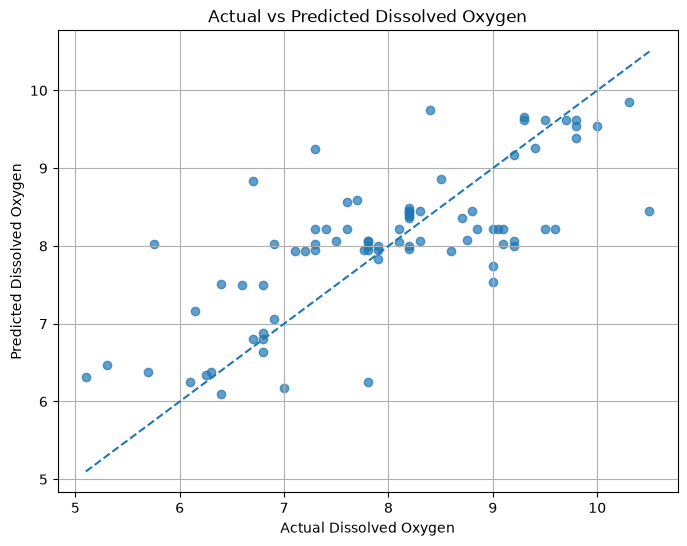

In [9]:
import matplotlib.pyplot as plt

# Create final best model pipeline
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

# Train best model
best_model.fit(X_train, y_train)

# Predictions
best_predictions = best_model.predict(X_test)

# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(y_test, best_predictions, alpha=0.7)

plt.xlabel("Actual Dissolved Oxygen")
plt.ylabel("Predicted Dissolved Oxygen")
plt.title("Actual vs Predicted Dissolved Oxygen")

# Perfect prediction reference line
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.grid(True)
plt.show()

In [10]:
# Select the best model
best_model_name = results_df.loc[
    results_df["R2 Score"].idxmax(), "Model"
]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [11]:
# Get the best trained model
best_pipeline = models[best_model_name]

print("Selected model pipeline:")
print(best_pipeline)

Selected model pipeline:
GradientBoostingRegressor(random_state=42)


In [12]:
import joblib
from pathlib import Path

# Create models directory
model_dir = ROOT / "models"
model_dir.mkdir(exist_ok=True)

# Save the trained model
model_path = model_dir / "best_water_quality_model.joblib"

joblib.dump(best_pipeline, model_path)

print("Model saved successfully!")
print("Location:", model_path)

Model saved successfully!
Location: /Users/ruchitanwar/TechStack/models/best_water_quality_model.joblib


In [14]:
# Load the saved model
loaded_model = joblib.load(model_path)

# Test prediction using one sample from test data
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Sample input:")
print(sample)

print("\nActual Dissolved Oxygen:", y_test.iloc[0])
print("Predicted Dissolved Oxygen:", prediction[0])

/Users/ruchitanwar/TechStack/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


ValueError: could not convert string to float: 'Uttar Pradesh'

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
import joblib

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

final_pipeline.fit(X_train, y_train)

model_path = ROOT / "models" / "best_water_quality_model.joblib"
joblib.dump(final_pipeline, model_path)

print("Final complete pipeline trained and saved!")
print("Location:", model_path)

Final complete pipeline trained and saved!
Location: /Users/ruchitanwar/TechStack/models/best_water_quality_model.joblib


In [16]:
# Final saved model prediction test

import joblib

# Load the final saved pipeline
loaded_model = joblib.load(model_path)

# Take one complete sample from the test dataset
sample = X_test.iloc[[0]].copy()

# Make prediction
predicted_do = loaded_model.predict(sample)[0]

# Actual value
actual_do = y_test.iloc[0]

print("MODEL PREDICTION TEST")
print("-" * 40)

print("\nInput:")
display(sample)

print(f"\nActual Dissolved Oxygen: {actual_do:.2f}")
print(f"Predicted Dissolved Oxygen: {predicted_do:.2f}")
print(f"Prediction Error: {abs(actual_do - predicted_do):.2f}")

MODEL PREDICTION TEST
----------------------------------------

Input:


,state,station_name,year
175,Uttar Pradesh,Prayagraj (Rasoolabad),2019.0



Actual Dissolved Oxygen: 8.20
Predicted Dissolved Oxygen: 8.44
Prediction Error: 0.24


In [17]:
print("=" * 50)
print("FINAL MODEL SUMMARY")
print("=" * 50)

best_result = results_df.loc[
    results_df["Model"] == best_model_name
].iloc[0]

print(f"\nBest Model: {best_model_name}")
print(f"MAE Score: {best_result['MAE']:.4f}")
print(f"RMSE Score: {best_result['RMSE']:.4f}")
print(f"R² Score: {best_result['R2 Score']:.4f}")

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

print("\nInput Features:")
for feature in X_train.columns:
    print("-", feature)

print("\nPrediction Target:")
print("- dissolved_oxygen")

print("\nModel Status: TRAINED AND SAVED SUCCESSFULLY")

FINAL MODEL SUMMARY

Best Model: Gradient Boosting
MAE Score: 0.6075
RMSE Score: 0.8095
R² Score: 0.5466

Training Samples: 328
Testing Samples: 82

Input Features:
- state
- station_name
- year

Prediction Target:
- dissolved_oxygen

Model Status: TRAINED AND SAVED SUCCESSFULLY
